<a href="https://colab.research.google.com/github/thorat1607/thorat1607/blob/OIBSIP/Task4_OIBSIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3>EMAIL SPAM DETECTION WITH MACHINE LEARNING

Import Libraries

In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

Read CSV file

In [7]:
df = pd.read_csv("/content/spam[1].csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Check any Null Values

In [8]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Remove Null Values

In [11]:
df = df.where((pd.notnull(df)),'')
df
df.isnull().sum()

v1            0
v2            0
Unnamed: 2    0
Unnamed: 3    0
Unnamed: 4    0
dtype: int64

Label Encoding

In [20]:
df.loc[df['v1'] == 'spam', 'v1',] = 0
df.loc[df['v1'] == 'ham', 'v1',] = 1

<AxesSubplot:xlabel='v1', ylabel='count'>

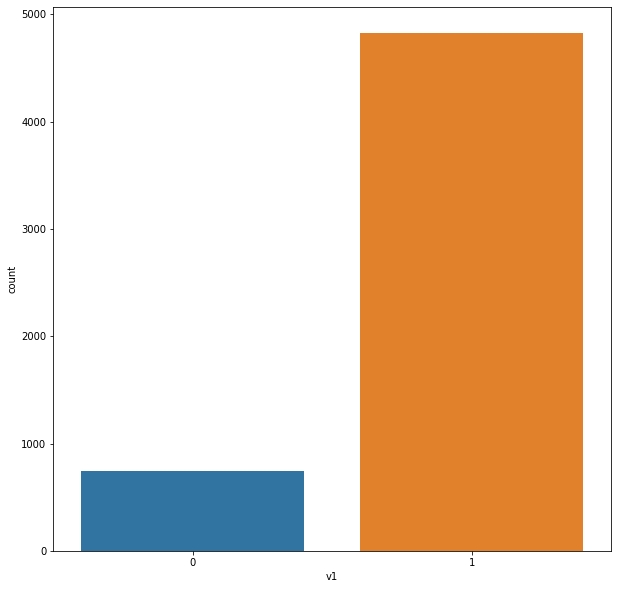

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,10))
sns.countplot(data = df, x= 'v1' )

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vect=TfidfVectorizer(min_df=1,stop_words='english',lowercase=True)

In [23]:
y = df['v1']

In [24]:
data = df.drop('v1',axis = 1)

Train and Fit Model

In [39]:
X_train, X_test, y_train, y_test = train_test_split(data, y, train_size = 0.8)
y_train = y_train.astype('int')
y_test = y_test.astype('int')

In [40]:
X_tr_f = vect.fit_transform(X_train['v2'])
X_te_f = vect.transform(X_test['v2'])

In [41]:
print(X_tr_f)

  (0, 1061)	0.3396858422063976
  (0, 6977)	0.19018832384830084
  (0, 6915)	0.4223575262987166
  (0, 5951)	0.4223575262987166
  (0, 6504)	0.3887433841262559
  (0, 2515)	0.4223575262987166
  (0, 6017)	0.4026945136339175
  (1, 1769)	0.5300005703680786
  (1, 2417)	0.3962895758048364
  (1, 5087)	0.355822777903715
  (1, 1848)	0.25582977526275147
  (1, 7340)	0.36320813170799526
  (1, 6745)	0.27504124203573643
  (1, 2092)	0.2895496247420314
  (1, 6139)	0.28033627554100765
  (2, 617)	0.4445991892803337
  (2, 3658)	0.42390070767355487
  (2, 5369)	0.3806472221627644
  (2, 1745)	0.34526293414214565
  (2, 1800)	0.3384463252184774
  (2, 4426)	0.4939585351409221
  (3, 5917)	0.6329925303520918
  (3, 2012)	0.5940528736914247
  (3, 3219)	0.4964087426480485
  (4, 5287)	0.6262447712350574
  :	:
  (4452, 4460)	0.3308228328077988
  (4452, 7360)	0.3259852828995909
  (4452, 845)	0.3259852828995909
  (4452, 2254)	0.22166230858368027
  (4452, 5272)	0.27709987933215774
  (4452, 6660)	0.26846560064089015
  (4452,

Logistic regression

In [42]:
model = LogisticRegression()
model.fit(X_tr_f,y_train)

LogisticRegression()

SVC

In [45]:
sv = SVC()
sv.fit(X_tr_f,y_train)

SVC()

MLP Classifier

In [46]:
nn = MLPClassifier(hidden_layer_sizes=(128,128))
nn.fit(X_tr_f,y_train)

MLPClassifier(hidden_layer_sizes=(128, 128))

In [48]:
model_pre = model.predict(X_te_f)
sv_pre = sv.predict(X_te_f)
nn_pre = nn.predict(X_te_f)

Accuracy Of algorithm

In [49]:
print(f'accuracy of Logistic Regression : {model.score(X_te_f,y_test)} ')
print(f'accuracy of SVM : {sv.score(X_te_f,y_test)} ')
print(f'accuracy of Neural Network : {nn.score(X_te_f,y_test)} ')

accuracy of Logistic Regression : 0.9524663677130045 
accuracy of SVM : 0.968609865470852 
accuracy of Neural Network : 0.9775784753363229 


F1-Score

In [51]:
print(f'F1 score of Logistic Regression : {f1_score(y_test,model_pre)} ')
print(f'F1 score of SVM : {f1_score(y_test,sv_pre)} ')
print(f'F1 score of Neural Network : {f1_score(y_test,nn_pre)} ')

F1 score of Logistic Regression : 0.9727786337955829 
F1 score of SVM : 0.9818558838776568 
F1 score of Neural Network : 0.9869723814486712 
